In [10]:
import os, sys, io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

IN_COLAB = 'google.colab' in sys.modules
print('Environment:', 'Google Colab' if IN_COLAB else 'Local Jupyter')

Environment: Google Colab


# Load Dataset

In [11]:
from pathlib import Path

if IN_COLAB:
    import ipywidgets as widgets
    from IPython.display import display
    uploader = widgets.FileUpload(accept='.csv', multiple=False)
    display(uploader)
    print('Select your CSV above, then run the next cell.')
else:
    # ── Local path — change this line ─────────────────────────────────────────
    FILE_PATH = Path('/Users/juliuskruger/Documents/Studium/Classwork/Spring 26/AI/gameandgrade.csv')
    # ──────────────────────────────────────────────────────────────────────────
    df = pd.read_csv(FILE_PATH)
    print(f'Loaded "{FILE_PATH.name}" — {df.shape[0]} rows x {df.shape[1]} columns')
    display(df.head())

FileUpload(value={}, accept='.csv', description='Upload')

Select your CSV above, then run the next cell.


In [12]:
# Colab only — run after uploading in the cell above
if IN_COLAB:
    if not uploader.value:
        raise RuntimeError('No file uploaded yet. Upload a CSV above, then re-run this cell.')
    # ipywidgets >= 8 returns a tuple of dicts; < 8 returns a dict keyed by filename
    if isinstance(uploader.value, dict):
        name = next(iter(uploader.value))
        raw  = uploader.value[name]['content']
    else:
        info = uploader.value[0]
        name = info['name']
        raw  = info['content']
    df = pd.read_csv(io.BytesIO(bytes(raw)))
    print(f'Loaded "{name}" — {df.shape[0]} rows x {df.shape[1]} columns')
    display(df.head())

Loaded "premier_league.csv" — 571 rows x 59 columns


,Name,Jersey Number,Club,Position,Nationality,Age,Appearances,Wins,Losses,Goals,...,Punches,High Claims,Catches,Sweeper clearances,Throw outs,Goal Kicks,Yellow cards,Red cards,Fouls,Offsides
0,Bernd Leno,1.0,Arsenal,Goalkeeper,Germany,28.0,64,28,16,0,...,34.0,26.0,17.0,28.0,375.0,489.0,2,0,0,NaN
1,Matt Macey,33.0,Arsenal,Goalkeeper,England,26.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN
2,RÃºnar Alex RÃºnarsson,13.0,Arsenal,Goalkeeper,Iceland,25.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN
3,HÃ©ctor BellerÃ­n,2.0,Arsenal,Defender,Spain,25.0,160,90,37,7,...,NaN,NaN,NaN,NaN,NaN,NaN,23,0,125,8.0
4,Kieran Tierney,3.0,Arsenal,Defender,Scotland,23.0,16,7,5,1,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0,9,0.0


# Data Observation

In [13]:
df.info()

num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()

print(f'Total rows: {len(df)}')
print(f'Numeric columns  ({len(num_cols)}): {num_cols}')
print(f'Categorical cols ({len(cat_cols)}): {cat_cols}')
print(f'\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().any().any() else 'None')

print(df[df['Position'] == 'Goalkeeper'].shape[0])
print(df[df['Position'] == 'Midfielder'].shape[0])
print(df[df['Position'] == 'Defender'].shape[0])
print(df[df['Position'] == 'Forward'].shape[0])


for col in num_cols:
    z_scores = stats.zscore(df[col].dropna())
    outliers = np.abs(z_scores) > 3

    print(f'Z-score analysis for "{col}":')
    print(f'  Total values    : {len(z_scores)}')
    print(f'  Outliers (|z|>3): {outliers.sum()} ({outliers.mean()*100:.1f}%)')
    print(f'  Min z-score     : {z_scores.min():.3f}')
    print(f'  Max z-score     : {z_scores.max():.3f}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 571 entries, 0 to 570
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    571 non-null    object 
 1   Jersey Number           563 non-null    float64
 2   Club                    571 non-null    object 
 3   Position                571 non-null    object 
 4   Nationality             570 non-null    object 
 5   Age                     570 non-null    float64
 6   Appearances             571 non-null    int64  
 7   Wins                    571 non-null    int64  
 8   Losses                  571 non-null    int64  
 9   Goals                   571 non-null    int64  
 10  Goals per match         309 non-null    float64
 11  Headed goals            502 non-null    float64
 12  Goals with right foot   502 non-null    float64
 13  Goals with left foot    502 non-null    float64
 14  Penalties scored        309 non-null    fl

In [14]:
df.describe()

,Jersey Number,Age,Appearances,Wins,Losses,Goals,Goals per match,Headed goals,Goals with right foot,Goals with left foot,...,Punches,High Claims,Catches,Sweeper clearances,Throw outs,Goal Kicks,Yellow cards,Red cards,Fouls,Offsides
count,563.000000,570.000000,571.000000,571.000000,571.000000,571.000000,309.000000,502.000000,502.000000,502.000000,...,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,571.000000,571.000000,571.000000,502.000000
mean,19.534636,25.789474,68.823117,28.957968,23.896673,7.327496,2.648414,1.414343,4.468127,2.388446,...,24.652174,45.869565,20.782609,25.565217,210.000000,414.144928,7.917688,0.301226,53.033275,11.063745
std,14.273515,4.377354,81.797516,38.969376,28.488376,16.810490,8.002117,3.433374,11.048341,6.295652,...,46.282644,82.332167,43.058397,47.333758,334.822473,641.246265,11.556811,0.698607,75.605560,26.570058
min,1.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000,22.000000,3.000000,1.000000,1.000000,0.000000,0.050000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,18.000000,26.000000,36.000000,12.000000,14.000000,1.000000,0.140000,0.000000,1.000000,0.000000,...,2.000000,6.000000,3.000000,4.000000,39.000000,53.000000,3.000000,0.000000,22.000000,2.000000
75%,27.000000,29.000000,108.000000,41.000000,36.000000,6.000000,0.390000,1.000000,3.000000,2.000000,...,31.000000,45.000000,17.000000,28.000000,300.000000,527.000000,11.000000,0.000000,74.000000,8.750000
max,82.000000,38.000000,539.000000,272.000000,158.000000,180.000000,57.000000,31.000000,127.000000,63.000000,...,269.000000,391.000000,249.000000,257.000000,1516.000000,2806.000000,81.000000,5.000000,438.000000,203.000000


# Data Preprocessing

1. Delete players with no appearances – cannot have Wins
2. Delete goalkeepers, too specific values – cause noise 
3. Delete tuples with missing values for age,nationality and jersey number
4. Delete Nationality column
5. Fix % data problem 
6. Delete Players who have less than 38 appearances
7. Split in different datasets based on position
8. Data reduction: linear regression to see what correlates the most with wins 

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

# 1. Delete players with no appearances
df = df[df['Appearances'] > 0]

# 2. Delete Goalkeepers – too position-specific, cause noise
df = df[df['Position'] != 'Goalkeeper']

# 3. Delete tuples with missing Age, Nationality, Jersey Number
df = df[df['Nationality'].notna()]
df = df[df['Age'].notna()]
df = df[df['Jersey Number'].notna()]

# 4. Delete Nationality column
df = df.drop(columns=['Nationality'])

# 5. Fix % data problem
df['Cross accuracy %']    = df['Cross accuracy %'].str.replace('%', '').astype(float)
df['Shooting accuracy %'] = df['Shooting accuracy %'].str.replace('%', '').astype(float)
df['Tackle success %']    = df['Tackle success %'].str.replace('%', '').astype(float)

# 6. Delete players with fewer than 38 appearances
df = df[df['Appearances'] >= 38]

# Normalize stats per appearance
features = df.columns
cols = features.drop(['Age', 'Name', 'Appearances', 'Club', 'Jersey Number', 'Cross accuracy %',
                      'Position', 'Goals per match', 'Passes per match',
                      'Tackle success %', 'Shooting accuracy %'])

data_clean_appNonZero = df.copy()
data_clean_appNonZero.loc[:, cols] = data_clean_appNonZero[cols].div(data_clean_appNonZero['Appearances'], axis=0)

# 7. Split by position (raw and normalized)
defenders   = df[df['Position'] == 'Defender']
midfielders = df[df['Position'] == 'Midfielder']
forwards    = df[df['Position'] == 'Forward']

defenders_   = data_clean_appNonZero[data_clean_appNonZero['Position'] == 'Defender']
midfielders_ = data_clean_appNonZero[data_clean_appNonZero['Position'] == 'Midfielder']
forwards_    = data_clean_appNonZero[data_clean_appNonZero['Position'] == 'Forward']

print(f'Defenders:   {len(defenders)}')
print(f'Midfielders: {len(midfielders)}')
print(f'Forwards:    {len(forwards)}')



Defenders:   97
Midfielders: 102
Forwards:    57


,Name,Jersey Number,Club,Position,Age,Appearances,Wins,Losses,Goals,Goals per match,...,Punches,High Claims,Catches,Sweeper clearances,Throw outs,Goal Kicks,Yellow cards,Red cards,Fouls,Offsides
3,HÃ©ctor BellerÃ­n,2.0,Arsenal,Defender,25.0,160,90,37,7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,23,0,125,8.0
6,Sokratis,5.0,Arsenal,Defender,32.0,44,21,11,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,18,0,56,1.0
7,Rob Holding,16.0,Arsenal,Defender,25.0,41,25,9,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,8,0,32,0.0
8,Shkodran Mustafi,20.0,Arsenal,Defender,28.0,99,52,26,7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,28,0,117,7.0
9,Calum Chambers,21.0,Arsenal,Defender,25.0,139,47,57,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,28,1,137,2.0


# Data Processing


 Defenders
R² Score: 0.5278
MAE: 0.0597  MSE: 0.0060  RMSE: 0.0774

Top 10 predictors:
                            Coef
Goals with left foot    5.128008
Goals with right foot   4.831410
Headed goals            4.351453
Goals                  -4.058588
Passes                  4.008809
Passes per match       -4.004559
Clearances off line     1.158618
Losses                 -0.961351
Hit woodwork           -0.599913
Errors leading to goal -0.457654


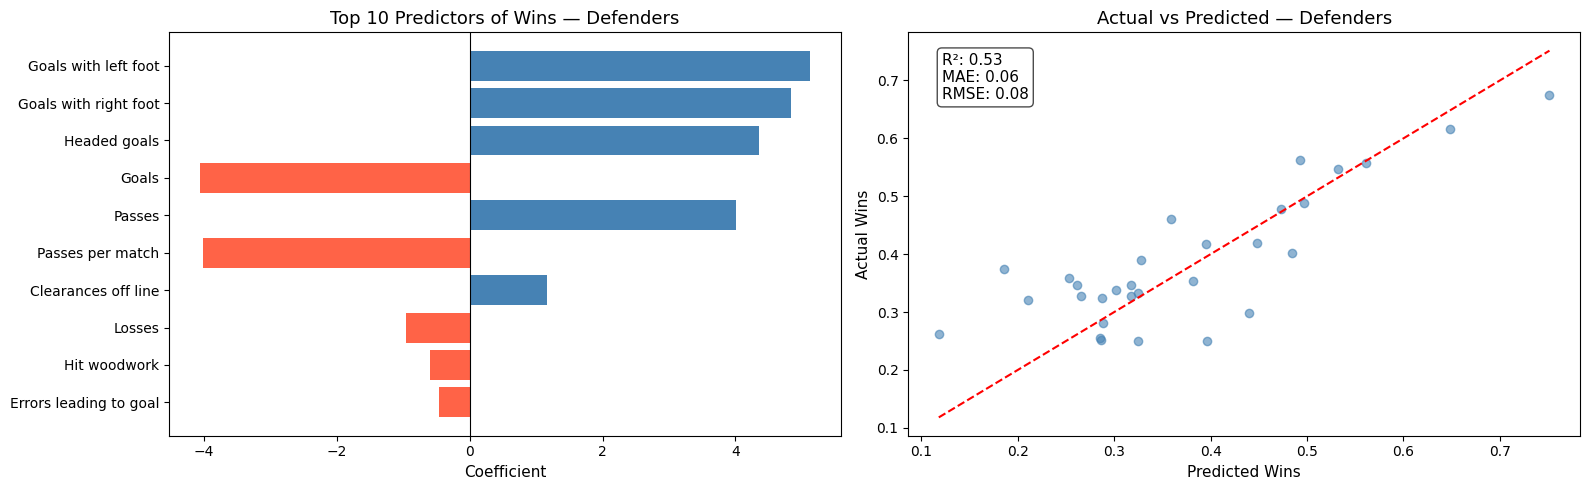


 Midfielders
R² Score: 0.3438
MAE: 0.0716  MSE: 0.0078  RMSE: 0.0880

Top 10 predictors:
                           Coef
Headed goals          -3.470691
Goals                  2.702225
Goals with right foot -2.349893
Goals with left foot  -2.197465
Passes per match       1.516937
Passes                -1.511665
Losses                -1.018655
Red cards             -0.836968
Yellow cards          -0.591924
Freekicks scored      -0.571862


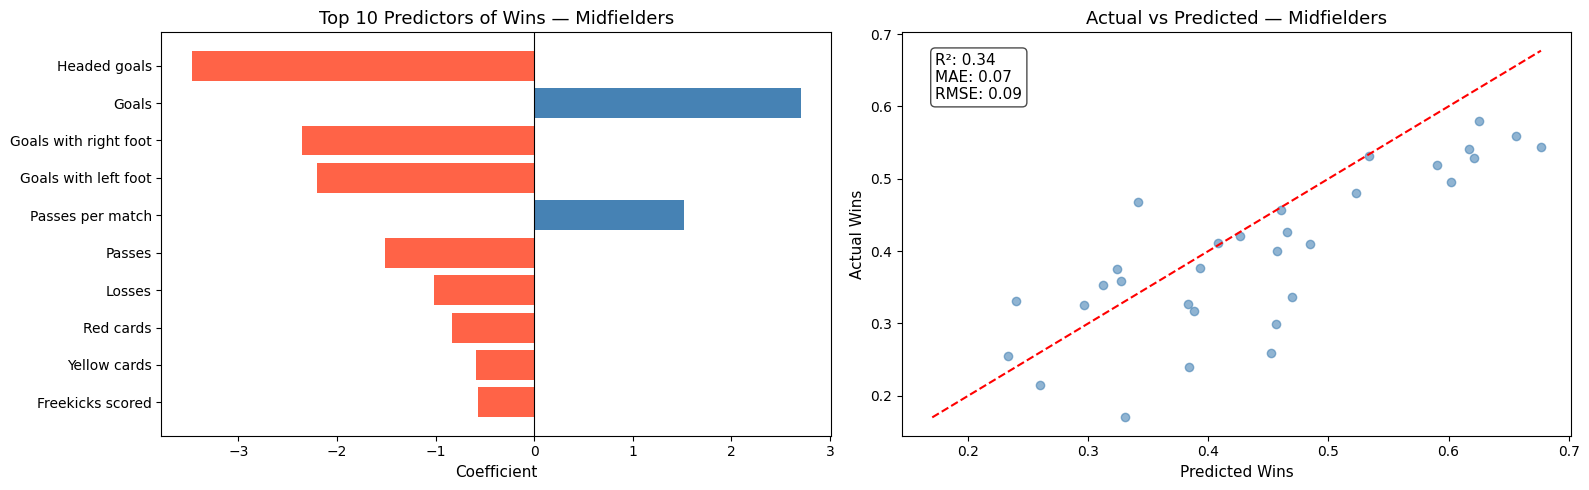


 Forwards
R² Score: 0.4721
MAE: 0.0868  MSE: 0.0131  RMSE: 0.1143

Top 10 predictors:
                            Coef
Goals                 -13.160464
Goals with left foot    7.698555
Headed goals            7.534148
Goals with right foot   7.396601
Goals per match         6.044439
Red cards              -3.343027
Passes per match        2.183574
Passes                 -2.182577
Yellow cards           -1.064785
Losses                 -0.898678


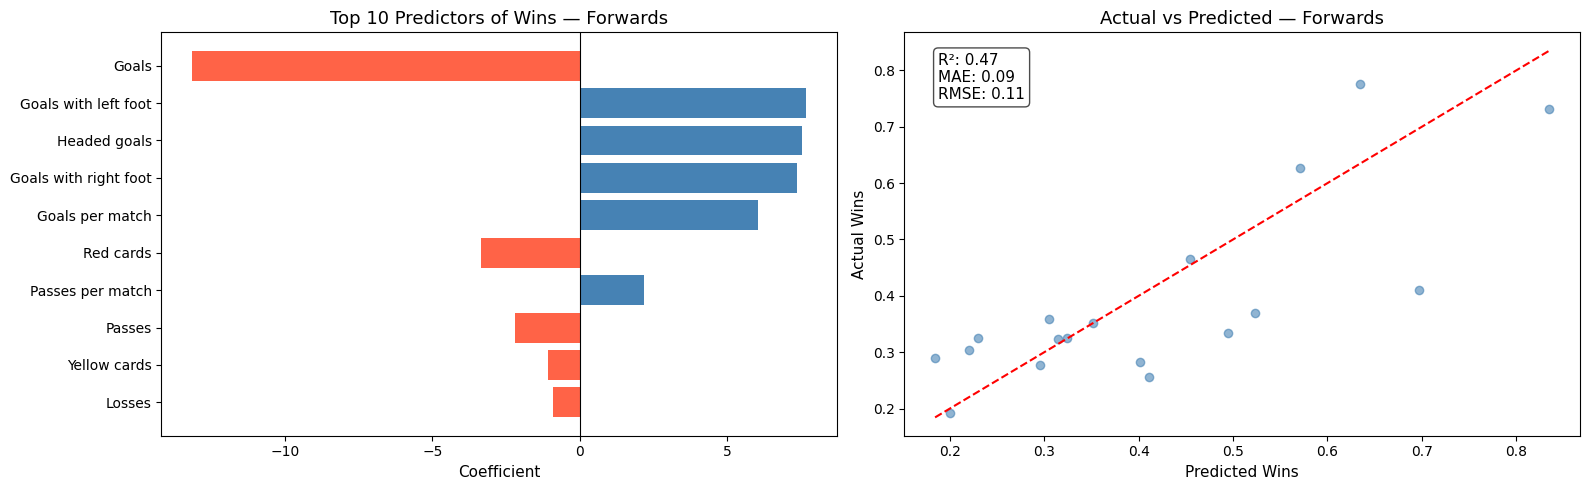

In [19]:
from sklearn.metrics import r2_score

position_sets = {
    'Defenders':   defenders_,
    'Midfielders': midfielders_,
    'Forwards':    forwards_
}

for position, dataset in position_sets.items():
    print(f'\n{"="*50}')
    print(f' {position}')
    print(f'{"="*50}')

    X = dataset.select_dtypes(include='number').drop(columns=['Wins'])
    y = dataset['Wins']

    X = X.dropna(axis=1, thresh=int(0.7 * len(X)))
    X = X.fillna(X.median())

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    lm = LinearRegression()
    lm.fit(X_train, y_train)
    prediction = lm.predict(X_test)

    mae  = mean_absolute_error(y_test, prediction)
    mse  = mean_squared_error(y_test, prediction)
    rmse = math.sqrt(mse)
    r2   = r2_score(y_test, prediction)

    print(f'R² Score: {r2:.4f}')
    print(f'MAE: {mae:.4f}  MSE: {mse:.4f}  RMSE: {rmse:.4f}')

    cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coef'])
    cdf = cdf.reindex(cdf['Coef'].abs().sort_values(ascending=False).index)
    print('\nTop 10 predictors:')
    print(cdf.head(10))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Bar chart
    top10 = cdf.head(10)
    colors = ['steelblue' if c > 0 else 'tomato' for c in top10['Coef']]
    axes[0].barh(top10.index, top10['Coef'], color=colors)
    axes[0].axvline(0, color='black', linewidth=0.8)
    axes[0].set_xlabel('Coefficient')
    axes[0].set_title(f'Top 10 Predictors of Wins — {position}')
    axes[0].invert_yaxis()

    # Scatter plot
    axes[1].scatter(prediction, y_test, alpha=0.6, color='steelblue')
    max_val = max(max(prediction), max(y_test))
    min_val = min(min(prediction), min(y_test))
    axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
    axes[1].set_xlabel('Predicted Wins')
    axes[1].set_ylabel('Actual Wins')
    axes[1].set_title(f'Actual vs Predicted — {position}')
    metrics_text = f"R²: {r2:.2f}\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}"
    axes[1].text(0.05, 0.95, metrics_text, transform=axes[1].transAxes,
                 fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    plt.tight_layout()
    plt.show()


**data set that unites all outfield positions – position specific is not enough data**

R² Score (test set):  0.8015
R² Score (full data): 0.8915
MAE: 0.0404  MSE: 0.0028  RMSE: 0.0532
Intercept: 0.8034

All predictors (sorted by |coefficient|):
                           Coef
Goals with left foot   1.992206
Goals with right foot  1.941573
Headed goals           1.875299
Goals                 -1.791149
Losses                -0.999076
Assists                0.325988
Red cards             -0.267178
Yellow cards          -0.254702
Big chances created   -0.213853
Passes                 0.108497
Passes per match      -0.106372
Hit woodwork           0.079003
Offsides              -0.032297
Blocked shots         -0.032146
Headed Clearance      -0.024451
Fouls                  0.011725
Clearances             0.009914
Crosses               -0.004110
Tackles               -0.003065
Age                   -0.002620
Interceptions         -0.001025
Jersey Number          0.000073
Appearances           -0.000016


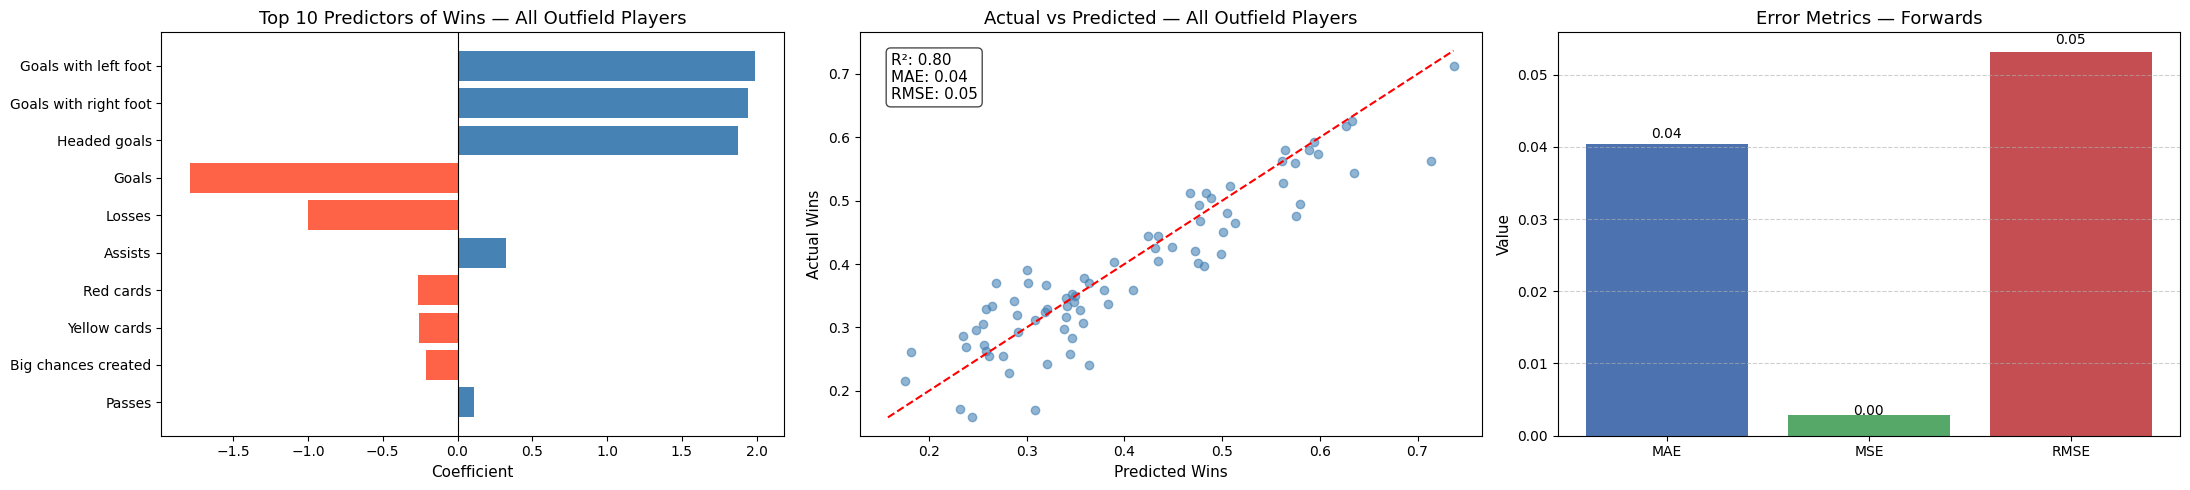

In [21]:
from sklearn.metrics import r2_score

# Combine all outfield players and fill missing values with N/A
all_outfield = pd.concat([defenders_, midfielders_, forwards_])
all_outfield = all_outfield.fillna('N/A')

# Linear regression for all outfield players
X = all_outfield.select_dtypes(include='number').drop(columns=['Wins'])
y = all_outfield['Wins']

X = X.dropna(axis=1, thresh=int(0.7 * len(X)))
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lm = LinearRegression()
lm.fit(X_train, y_train)
prediction = lm.predict(X_test)

mae  = mean_absolute_error(y_test, prediction)
mse  = mean_squared_error(y_test, prediction)
rmse = math.sqrt(mse)
r2   = r2_score(y_test, prediction)
r2_full = lm.score(X, y)


print(f'R² Score (test set):  {r2:.4f}')
print(f'R² Score (full data): {r2_full:.4f}')
print(f'MAE: {mae:.4f}  MSE: {mse:.4f}  RMSE: {rmse:.4f}')
print(f'Intercept: {lm.intercept_:.4f}')


cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coef'])
cdf = cdf.reindex(cdf['Coef'].abs().sort_values(ascending=False).index)
print('\nAll predictors (sorted by |coefficient|):')
print(cdf.to_string())


fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Bar chart
top10 = cdf.head(10)
colors = ['steelblue' if c > 0 else 'tomato' for c in top10['Coef']]
axes[0].barh(top10.index, top10['Coef'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Coefficient')
axes[0].set_title('Top 10 Predictors of Wins — All Outfield Players')
axes[0].invert_yaxis()

# Scatter plot
axes[1].scatter(prediction, y_test, alpha=0.6, color='steelblue')
max_val = max(max(prediction), max(y_test))
min_val = min(min(prediction), min(y_test))
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
axes[1].set_xlabel('Predicted Wins')
axes[1].set_ylabel('Actual Wins')
axes[1].set_title('Actual vs Predicted — All Outfield Players')
metrics_text = f"R²: {r2:.2f}\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}"
axes[1].text(0.05, 0.95, metrics_text, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

# Standalone error metric bar chart
metric_names = ['MAE', 'MSE', 'RMSE']
metric_vals  = [mae, mse, rmse]
bars = axes[2].bar(metric_names, metric_vals, color=['#4C72B0', '#55A868', '#C44E52'])
axes[2].set_title(f'Error Metrics — {position}')
axes[2].set_ylabel('Value')
axes[2].grid(axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars, metric_vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2, val * 1.02,
                 f'{val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


R2 for split datasets is way too low, most likely because of too few data. The united data set has a much better R2 of .8, which is acceptable, but it could be better. A limitation here is the variation in available data. Linear regression is as the name suggest linear and does not catch related data points. So for instance wins if goals AND assists. Thats why we will try a Decision Tree now. 

All Outfield Players — Decision Tree
R² Score (test set):  0.6993
R² Score (full data): 0.9120
MAE: 0.0476  MSE: 0.0043  RMSE: 0.0655
Tree depth: 5  |  Leaves: 28

All predictors (sorted by importance):
                       Importance
Losses                   0.948129
Age                      0.010749
Yellow cards             0.009589
Assists                  0.006939
Blocked shots            0.005988
Big chances created      0.005146
Jersey Number            0.003747
Tackles                  0.003191
Passes                   0.002642
Clearances               0.002041
Fouls                    0.001066
Hit woodwork             0.000394
Goals with right foot    0.000369
Crosses                  0.000011
Appearances              0.000000
Headed goals             0.000000
Goals                    0.000000
Goals with left foot     0.000000
Interceptions            0.000000
Headed Clearance         0.000000
Passes per match         0.000000
Red cards                0.000000
Offsides       

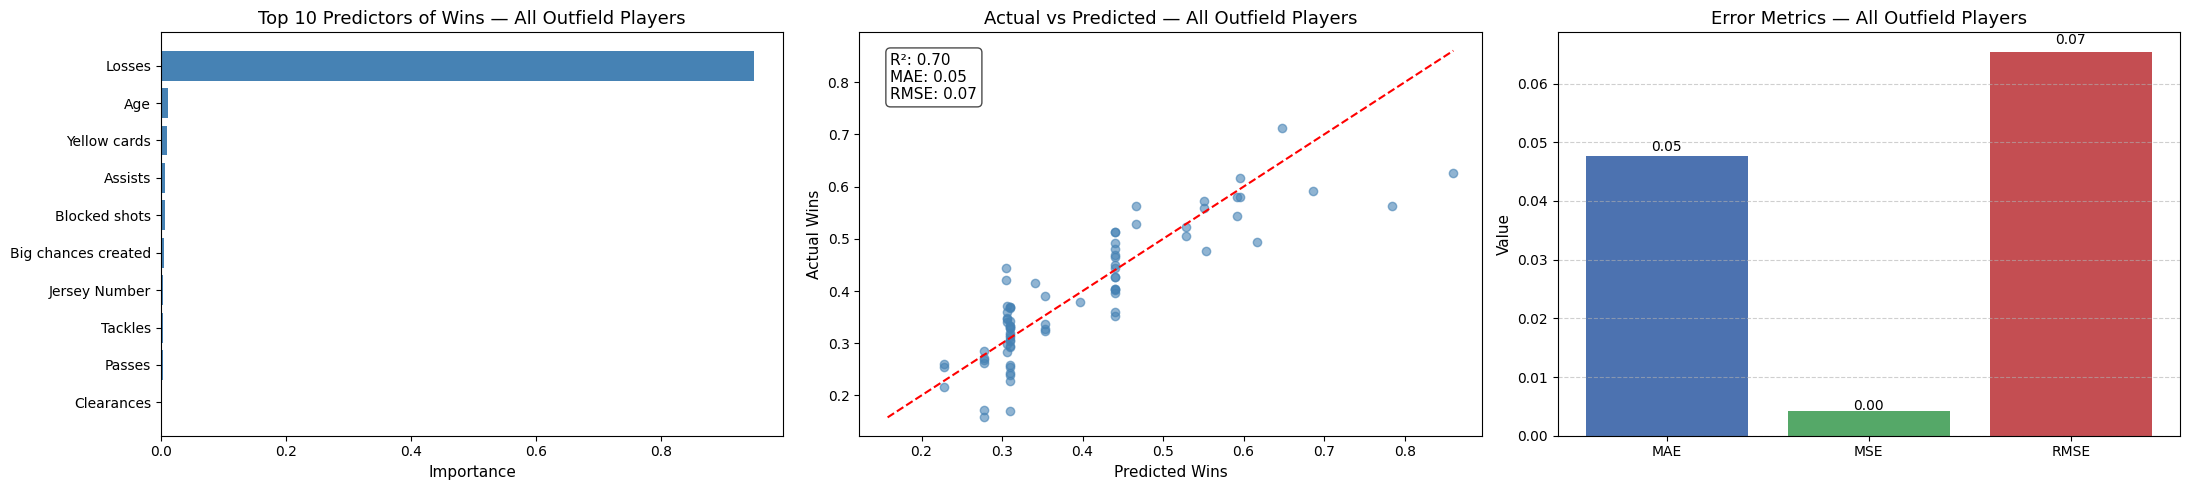

In [31]:
from sklearn.tree import DecisionTreeRegressor

all_outfield = pd.concat([defenders_, midfielders_, forwards_])
all_outfield = all_outfield.fillna('N/A')

X = all_outfield.select_dtypes(include='number').drop(columns=['Wins'])
y = all_outfield['Wins']

X = X.dropna(axis=1, thresh=int(0.7 * len(X)))
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
prediction = dt.predict(X_test)

mae     = mean_absolute_error(y_test, prediction)
mse     = mean_squared_error(y_test, prediction)
rmse    = math.sqrt(mse)
r2      = r2_score(y_test, prediction)
r2_full = dt.score(X, y)

print('All Outfield Players — Decision Tree')
print(f'R² Score (test set):  {r2:.4f}')
print(f'R² Score (full data): {r2_full:.4f}')
print(f'MAE: {mae:.4f}  MSE: {mse:.4f}  RMSE: {rmse:.4f}')
print(f'Tree depth: {dt.get_depth()}  |  Leaves: {dt.get_n_leaves()}')

cdf = pd.DataFrame(dt.feature_importances_, X.columns, columns=['Importance'])
cdf = cdf.sort_values('Importance', ascending=False)
print('\nAll predictors (sorted by importance):')
print(cdf.to_string())

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

top10 = cdf.head(10)
axes[0].barh(top10.index, top10['Importance'], color='steelblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 10 Predictors of Wins — All Outfield Players')
axes[0].invert_yaxis()

axes[1].scatter(prediction, y_test, alpha=0.6, color='steelblue')
max_val = max(max(prediction), max(y_test))
min_val = min(min(prediction), min(y_test))
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
axes[1].set_xlabel('Predicted Wins')
axes[1].set_ylabel('Actual Wins')
axes[1].set_title('Actual vs Predicted — All Outfield Players')
metrics_text = f"R²: {r2:.2f}\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}"
axes[1].text(0.05, 0.95, metrics_text, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

metric_names = ['MAE', 'MSE', 'RMSE']
metric_vals  = [mae, mse, rmse]
bars = axes[2].bar(metric_names, metric_vals, color=['#4C72B0', '#55A868', '#C44E52'])
axes[2].set_title('Error Metrics — All Outfield Players')
axes[2].set_ylabel('Value')
axes[2].grid(axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars, metric_vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2, val * 1.02,
                 f'{val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


Data is overfit, because r2 test is much larger than r2 full. Linear regression worked better and got a mediocre - decent result. The limitation is the small size of the data and the massive lack of data. The data cannot be added by most probable data, because the missing data is position-specific. Thus, we have a lack of comparative tuples. 